In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_json('../data/processed/streaming_users_clean.json')  # Replace 'data.csv' with your actual data file path

df.shape

(7251, 8)

# Variables utilizadas #

Seleccionamos las 3 variables numericas del dataset (age, monthly_watch_time_mins, customer_support_tickets). Ya que estas variables describen dimensiones distintas del comportamiento del usuario: perfil demográfico, consumo, experiencia técnica y actividad recientes, mientras que el resto de columnas fueron excluidas ya que pca solo trabaja con variables numericas

In [14]:
# --- SECCIÓN 1: Variables Utilizadas ---
print("\n=== 1. VARIABLES UTILIZADAS ===\n")

# Seleccionar variables numéricas para PCA
variables_pca = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']

print("Variables seleccionadas para PCA:")
for var in variables_pca:
    print(f"  - {var}")

# Crear DataFrame con las variables seleccionadas
df_pca = df[variables_pca].copy()


=== 1. VARIABLES UTILIZADAS ===

Variables seleccionadas para PCA:
  - age
  - monthly_watch_time_mins
  - customer_support_tickets


### Escalamiento ###

tomamos las variables seleccionadas para PCA (df_pca) y las estandarizo usando StandardScaler, que es obligatorio antes de aplicar PCA porque el algoritmo es sensible a la escala de las variables: si no se escala, una variable como monthly_watch_time_mins (que puede llegar a varios miles) pesaría mucho más que otra como customer_support_tickets (que suele tener valores bajos de un solo dígito), no porque sea más importante, sino simplemente por su magnitud. El fit_transform calcula la media y el desvío de cada variable y las transforma para que todas queden con media 0 y desvío estándar 1, y después se reconstruye como DataFrame (df_scaled) para poder inspeccionar los resultados fácilmente

In [15]:
# --- SECCIÓN 2: Escalamiento ---
print("\n=== 2. ESCALAMIENTO ===\n")

# Crear el escalador
scaler = StandardScaler() 

# Aplicar escalamiento
df_scaled = scaler.fit_transform(df_pca)

# Convertir a DataFrame para mejor visualización
df_scaled = pd.DataFrame(df_scaled, columns=variables_pca)

print("Escalamiento aplicado: StandardScaler (media=0, desviación=1)")

# Mostrar estadísticas después del escalamiento
print("\nEstadísticas después del escalamiento:")
print(df_scaled.describe().round(2))

# Verificar que la media sea 0
print("\nMedias después del escalamiento:")
print(df_scaled.mean().round(2))


=== 2. ESCALAMIENTO ===

Escalamiento aplicado: StandardScaler (media=0, desviación=1)

Estadísticas después del escalamiento:
           age  monthly_watch_time_mins  customer_support_tickets
count  7251.00                  7251.00                   7251.00
mean     -0.00                    -0.00                     -0.00
std       1.00                     1.00                      1.00
min      -2.54                    -1.60                     -0.24
25%      -0.73                    -0.61                     -0.15
50%      -0.05                    -0.08                     -0.07
75%       0.72                     0.49                     -0.07
max       3.98                     6.82                     12.64

Medias después del escalamiento:
age                        -0.0
monthly_watch_time_mins    -0.0
customer_support_tickets   -0.0
dtype: float64


### Aplicacion de PCA ###

Aplicamos PCA con todas las componentes posibles (3) para poder ver el aporte de cada una antes de recortar (varianza). La varianza explicada por cada componente indica cuánta información del dataset original captura esa dimensión reducida.

In [16]:
# --- SECCIÓN 3: Aplicación de PCA y Varianza Explicada ---
print("\n=== 3. APLICACIÓN DE PCA Y VARIANZA EXPLICADA ===\n")

# Aplicar PCA
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

df_pca_result = pd.DataFrame(
    pca_result, 
    columns=[f'PC{i+1}' for i in range(len(variables_pca))]
)

# Calcular varianza
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print("Varianza explicada por cada componente:")
for i, (var, acum) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f"  PC{i+1}: {var*100:.2f}% (Acumulada: {acum*100:.2f}%)")

print(f"\nVarianza total explicada por las 3 componentes: {varianza_acumulada[-1]*100:.2f}%")

print("\nLoadings (peso) de las variables en cada componente:")
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(variables_pca))],
    index=variables_pca
)
print(loadings.round(3))


=== 3. APLICACIÓN DE PCA Y VARIANZA EXPLICADA ===

Varianza explicada por cada componente:
  PC1: 33.68% (Acumulada: 33.68%)
  PC2: 33.42% (Acumulada: 67.10%)
  PC3: 32.90% (Acumulada: 100.00%)

Varianza total explicada por las 3 componentes: 100.00%

Loadings (peso) de las variables en cada componente:
                            PC1    PC2    PC3
age                       0.259  0.858 -0.443
monthly_watch_time_mins   0.737  0.121  0.665
customer_support_tickets -0.624  0.499  0.602


### 1ra Visualización ###

Aqui podemos ver que los 3 componentes cuentan con proporciones bastante similares
    ► PC1 (33,7%)
    ► PC2 (33,4%)
    ► PC3 (32,9%)


=== 4. VISUALIZACIÓN 1 — VARIANZA EXPLICADA POR COMPONENTE ===



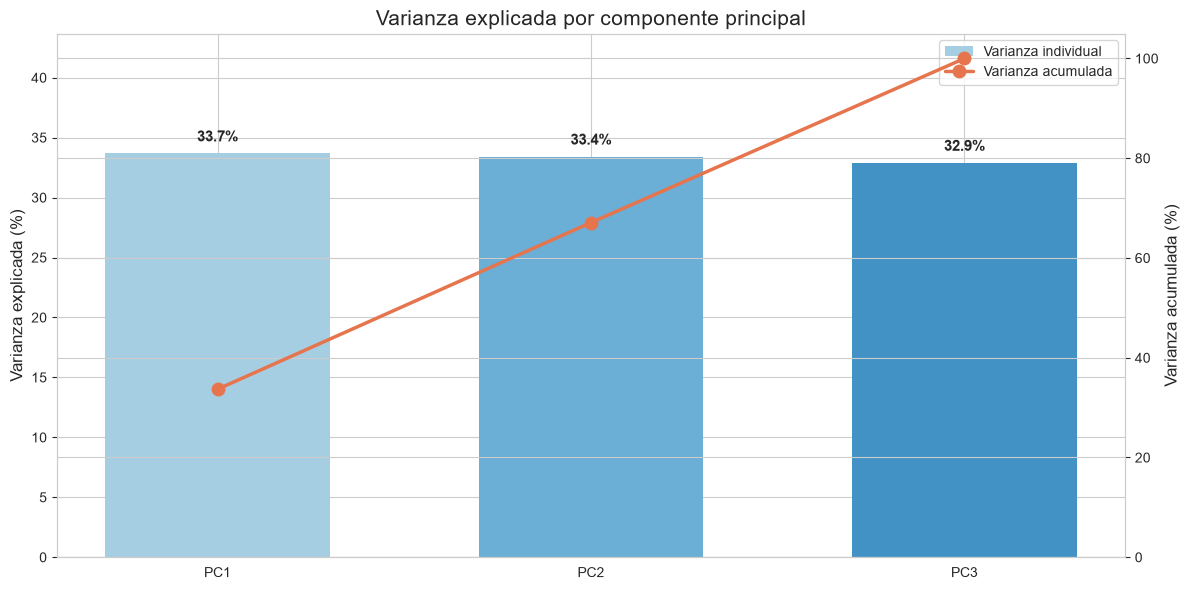

In [17]:
# SECCIÓN 4: Visualización 1 
print("\n=== 4. VISUALIZACIÓN 1 — VARIANZA EXPLICADA POR COMPONENTE ===\n")

fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(1, len(varianza_explicada) + 1)

colores = ['#a6cee3', '#6baed6', '#4292c6', '#2166ac']  # degradé de celeste a azul oscuro
bars = ax1.bar(x, varianza_explicada * 100, width=0.6, 
                color=colores[:len(varianza_explicada)], 
                edgecolor='none', label='Varianza individual')

for i, v in enumerate(varianza_explicada):
    ax1.text(i + 1, v * 100 + 1, f'{v*100:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax1.set_xlabel('')
ax1.set_ylabel('Varianza explicada (%)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels([f'PC{i+1}' for i in range(len(varianza_explicada))])
ax1.set_ylim(0, max(varianza_explicada * 100) + 10)

ax2 = ax1.twinx()
ax2.plot(x, varianza_acumulada * 100, marker='o', linewidth=2.5, markersize=9, 
         color='#e6754e', label='Varianza acumulada')
ax2.set_ylabel('Varianza acumulada (%)', fontsize=12)
ax2.set_ylim(0, 105)

# Título
plt.title('Varianza explicada por componente principal', fontsize=15)

# Combinar leyendas de ambos ejes en una sola caja
bars_legend, bars_labels = ax1.get_legend_handles_labels()
line_legend, line_labels = ax2.get_legend_handles_labels()
ax1.legend(bars_legend + line_legend, bars_labels + line_labels, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

### Visualizacion 2 (loadigs) ###

Calculamos y graficamos los "loadings" de pca, para despues interpretarlos automaticamente

► Extracción de loandings: pca.components_[0] y [1] son los loadings de PC1 y PC2, basicamente el peso que tiene cada variable      

► despues lo visualizamos en un grafico de barras, la cual nos ayudara a ver mas rapido que variables aportan positivoo o negaativo


=== 5. VISUALIZACIÓN 2 — CONTRIBUCIÓN DE VARIABLES A PC1 Y PC2 ===

Loadings de las variables en PC1 y PC2:
                   Variable    PC1    PC2
0                       age  0.259  0.858
1   monthly_watch_time_mins  0.737  0.121
2  customer_support_tickets -0.624  0.499


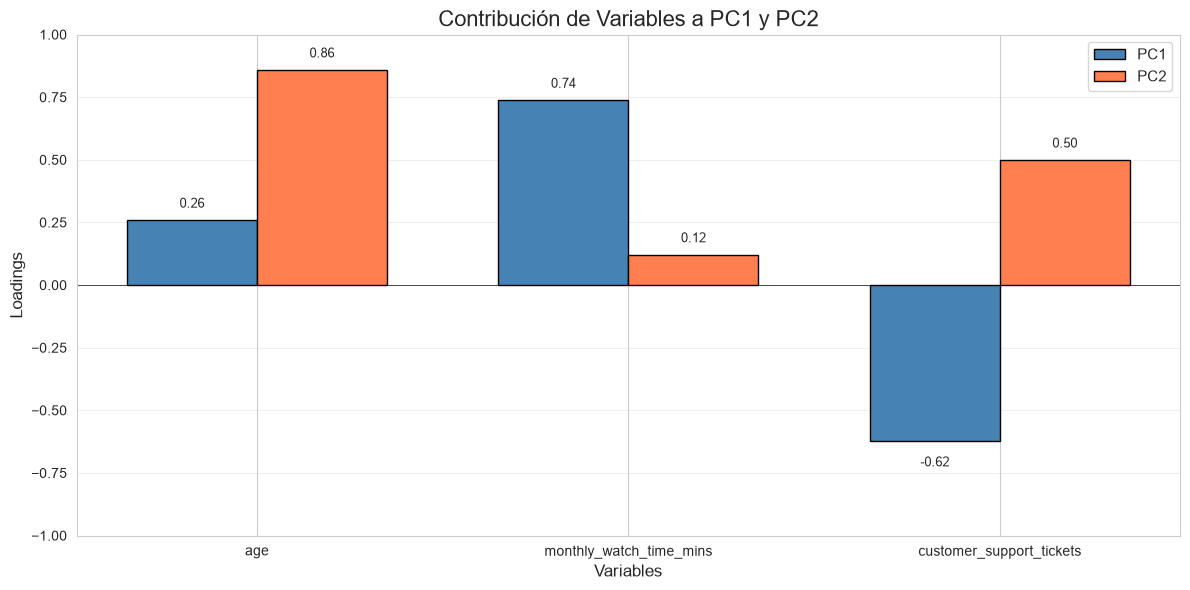


PC1 (Primera Componente):
  - age: 0.26 (contribución positiva, intensidad baja)
  - monthly_watch_time_mins: 0.74 (contribución positiva, intensidad alta)
  - customer_support_tickets: -0.62 (contribución negativa, intensidad alta)

PC2 (Segunda Componente):
  - age: 0.86 (contribución positiva, intensidad alta)
  - monthly_watch_time_mins: 0.12 (contribución positiva, intensidad baja)
  - customer_support_tickets: 0.50 (contribución positiva, intensidad media)


In [18]:
# SECCIÓN 5: Visualización 2 
print("\n=== 5. VISUALIZACIÓN 2 — CONTRIBUCIÓN DE VARIABLES A PC1 Y PC2 ===\n")

loadings_pc1 = pca.components_[0]
loadings_pc2 = pca.components_[1]

loadings_df = pd.DataFrame({
    'Variable': variables_pca,
    'PC1': loadings_pc1,
    'PC2': loadings_pc2
})

print("Loadings de las variables en PC1 y PC2:")
print(loadings_df.round(3))

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(variables_pca))
width = 0.35

bars1 = ax.bar(x - width/2, loadings_pc1, width, label='PC1', 
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, loadings_pc2, width, label='PC2', 
               color='coral', edgecolor='black')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Contribución de Variables a PC1 y PC2', fontsize=16)
ax.set_xlabel('Variables', fontsize=12)
ax.set_ylabel('Loadings', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(variables_pca)
ax.set_ylim(-1, 1)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(loadings_pc1):
    ax.text(i - width/2, v + (0.05 if v >= 0 else -0.1), f'{v:.2f}', 
            ha='center', fontsize=9)

for i, v in enumerate(loadings_pc2):
    ax.text(i + width/2, v + (0.05 if v >= 0 else -0.1), f'{v:.2f}', 
            ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nPC1 (Primera Componente):")
for var, loading in zip(variables_pca, loadings_pc1):
    direccion = "positiva" if loading > 0 else "negativa"
    intensidad = "alta" if abs(loading) > 0.5 else "media" if abs(loading) > 0.3 else "baja"
    print(f"  - {var}: {loading:.2f} (contribución {direccion}, intensidad {intensidad})")

print("\nPC2 (Segunda Componente):")
for var, loading in zip(variables_pca, loadings_pc2):
    direccion = "positiva" if loading > 0 else "negativa"
    intensidad = "alta" if abs(loading) > 0.5 else "media" if abs(loading) > 0.3 else "baja"
    print(f"  - {var}: {loading:.2f} (contribución {direccion}, intensidad {intensidad})")

### Interpretación ###

#### Varianza ####

Las tres componentes explican proporciones muy similares de la varianza total:

► PC1: 33.68%

► PC2: 33.42%

► PC3: 32.90%

Esto implica que la varianza se distribuye de forma casi uniforme entre las tres variables originales. Este resultado confirma lo que el análisis exploratorio ya sugería: las variables no están fuertemente correlacionadas entre sí, por lo que cada una aporta información independiente y PCA no puede comprimir el dataset sin pérdida significativa.
Retener 2 componentes implicaría conservar solo el 67.1% de la información original, lo cual no representa una reducción de dimensionalidad útil en términos prácticos. Para capturar el 100% de la varianza se requieren las 3 componentes originales. En este caso, la reducción de dimensionalidad no es el resultado buscado: el resultado relevante es entender qué estructura captura cada componente.

#### Loandings ####

PC1 (Primera Componente):
monthly_watch_time_mins: 0.74 (contribución positiva, intensidad alta)
customer_support_tickets: -0.62 (contribución negativa, intensidad alta)
age: 0.26 (contribución positiva, intensidad baja)

PC1 contrasta el tiempo de visualización contra los tickets de soporte. Los usuarios con valores altos en PC1 son aquellos que ven más minutos, tienen mayor edad y reportan menos problemas (tickets negativos). Por el contrario, los usuarios con valores bajos en PC1 son aquellos que ven menos contenido, son más jóvenes y tienen más tickets de soporte.
Esto puese interpretarse como una dimensión de "calidad de experiencia": usuarios con alta visualización y bajos tickets (experiencia positiva) vs. usuarios con baja visualización y altos tickets (experiencia negativa).

PC2 (Segunda Componente):
age: 0.86 (contribución positiva, intensidad alta)
customer_support_tickets: 0.50 (contribución positiva, intensidad media)
monthly_watch_time_mins: 0.12 (contribución positiva, intensidad baja)

PC2 está dominada casi exclusivamente por la edad del usuario. Los usuarios con valores altos en PC2 son personas mayores, que además tienden a tener más tickets de soporte. Los usuarios con valores bajos en PC2 son personas más jóvenes, con menos tickets.
Esto puede interpretarse como una dimensión de "perfil etario": separa a los usuarios mayores (con más tickets) de los jóvenes (con menos tickets).